In [1]:
# import libaries
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
from PIL import Image

In [2]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("AI VISION SYSTEM")
print("STAGE 1: FACE DETECTION + ENHANCEMENT")
print("=" * 60)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

AI VISION SYSTEM
STAGE 1: FACE DETECTION + ENHANCEMENT
Device: cuda
GPU: NVIDIA GeForce RTX 2050


In [3]:
# PROJECT DIRECTORIES


PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"


for directory in [
    DATA_DIR,
    RAW_DIR,
    PROCESSED_DIR,
    MODELS_DIR,
    OUTPUTS_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print("Project root:")
print(PROJECT_ROOT)

print("\nProject directories:")

print("RAW       :", RAW_DIR)
print("PROCESSED :", PROCESSED_DIR)
print("MODELS    :", MODELS_DIR)
print("OUTPUTS   :", OUTPUTS_DIR)

Project root:
e:\Pyhton code\Deep Learning\CNN\Face Recognition Model

Project directories:
RAW       : e:\Pyhton code\Deep Learning\CNN\Face Recognition Model\data\raw
PROCESSED : e:\Pyhton code\Deep Learning\CNN\Face Recognition Model\data\processed
MODELS    : e:\Pyhton code\Deep Learning\CNN\Face Recognition Model\models
OUTPUTS   : e:\Pyhton code\Deep Learning\CNN\Face Recognition Model\outputs


In [4]:
# FACE DETECTOR


CASCADE_PATH = (
    cv2.data.haarcascades
    + "haarcascade_frontalface_default.xml"
)

face_detector = cv2.CascadeClassifier(
    CASCADE_PATH
)


if face_detector.empty():
    raise RuntimeError(
        "Could not load Haar Cascade face detector."
    )


print("Face detector loaded successfully!")
print("Detector:", CASCADE_PATH)

Face detector loaded successfully!
Detector: C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\cv2\data\haarcascade_frontalface_default.xml


In [ ]:
# IMAGE LOADER

def load_image(image_path):

    image = Image.open(
        image_path
    ).convert("RGB")

    return image


print("Image loader ready!")

Image loader ready!


In [ ]:
#Face Detector

def detect_faces(
    image,
    scale_factor=1.1,
    min_neighbors=5,
    min_size=(40, 40)
):

    image_np = np.array(
        image
    )

    gray = cv2.cvtColor(
        image_np,
        cv2.COLOR_RGB2GRAY
    )

    detections = face_detector.detectMultiScale(
        gray,
        scaleFactor=scale_factor,
        minNeighbors=min_neighbors,
        minSize=min_size
    )

    boxes = []

    for x, y, w, h in detections:

        x1 = int(x)
        y1 = int(y)

        x2 = int(x + w)
        y2 = int(y + h)

        boxes.append(
            (x1, y1, x2, y2)
        )

    return boxes


print("Face detection function ready!")

Face detection function ready!


In [7]:
#Face Cropping

def crop_face(
    image,
    box,
    padding=0.25
):

    width, height = image.size

    x1, y1, x2, y2 = box

    face_width = x2 - x1
    face_height = y2 - y1

    pad_x = int(
        face_width * padding
    )

    pad_y = int(
        face_height * padding
    )

    x1 = max(
        0,
        x1 - pad_x
    )

    y1 = max(
        0,
        y1 - pad_y
    )

    x2 = min(
        width,
        x2 + pad_x
    )

    y2 = min(
        height,
        y2 + pad_y
    )

    face = image.crop(
        (x1, y1, x2, y2)
    )

    return face


print("Face cropping function ready!")

Face cropping function ready!


In [ ]:
#Image Quality

def calculate_sharpness(face):

    face_np = np.array(
        face
    )

    gray = cv2.cvtColor(
        face_np,
        cv2.COLOR_RGB2GRAY
    )

    sharpness = cv2.Laplacian(
        gray,
        cv2.CV_64F
    ).var()

    return float(sharpness)


def calculate_brightness(face):
    
    face_np = np.array(
        face
    )

    gray = cv2.cvtColor(
        face_np,
        cv2.COLOR_RGB2GRAY
    )

    brightness = np.mean(
        gray
    )

    return float(brightness)


print("Image quality functions ready!")

Image quality functions ready!


In [9]:
#Adaptive Enhancement

def enhance_face(
    face,
    upscale_factor=2
):

    face_np = np.array(
        face
    )

    # 1. UPSCALE


    height, width = face_np.shape[:2]

    new_width = width * upscale_factor
    new_height = height * upscale_factor

    upscaled = cv2.resize(
        face_np,
        (
            new_width,
            new_height
        ),
        interpolation=cv2.INTER_CUBIC
    )

    # 2. DENOISING


    denoised = cv2.fastNlMeansDenoisingColored(
        upscaled,
        None,
        h=5,
        hColor=5,
        templateWindowSize=7,
        searchWindowSize=21
    )

    # 3. CLAHE

    lab = cv2.cvtColor(
        denoised,
        cv2.COLOR_RGB2LAB
    )

    l_channel, a_channel, b_channel = (
        cv2.split(lab)
    )

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l_channel = clahe.apply(
        l_channel
    )

    enhanced_lab = cv2.merge(
        (
            l_channel,
            a_channel,
            b_channel
        )
    )

    enhanced = cv2.cvtColor(
        enhanced_lab,
        cv2.COLOR_LAB2RGB
    )

    # 4. SHARPENING

    blurred = cv2.GaussianBlur(
        enhanced,
        (0, 0),
        sigmaX=1.0
    )

    sharpened = cv2.addWeighted(
        enhanced,
        1.5,
        blurred,
        -0.5,
        0
    )

    # Prevent invalid pixel values
    sharpened = np.clip(
        sharpened,
        0,
        255
    ).astype(
        np.uint8
    )

    return Image.fromarray(
        sharpened
    )


print("Face enhancement function ready!")

Face enhancement function ready!


In [10]:
# ADAPTIVE ENHANCEMENT DECISION

SHARPNESS_THRESHOLD = 100.0

BRIGHTNESS_LOW = 50.0
BRIGHTNESS_HIGH = 210.0


def should_enhance(face):

    sharpness = calculate_sharpness(
        face
    )

    brightness = calculate_brightness(
        face
    )

    low_sharpness = (
        sharpness < SHARPNESS_THRESHOLD
    )

    bad_brightness = (
        brightness < BRIGHTNESS_LOW
        or
        brightness > BRIGHTNESS_HIGH
    )

    enhance = (
        low_sharpness
        or
        bad_brightness
    )

    return (
        enhance,
        sharpness,
        brightness
    )


print("Adaptive enhancement decision system ready!")

Adaptive enhancement decision system ready!


In [11]:
# UNIFIED FACE PREPROCESSING

RECOGNITION_SIZE = 224


def preprocess_face(
    face,
    apply_enhancement=True
):

    enhancement_applied = False
    
    # QUALITY CHECK

    if apply_enhancement:

        enhance_required, sharpness, brightness = (
            should_enhance(face)
        )

        if enhance_required:

            face = enhance_face(
                face
            )

            enhancement_applied = True

    else:

        sharpness = calculate_sharpness(
            face
        )

        brightness = calculate_brightness(
            face
        )

#    Resize

    face = face.resize(
        (
            RECOGNITION_SIZE,
            RECOGNITION_SIZE
        ),
        Image.Resampling.BILINEAR
    )
#   PIL -> Image

    face_np = np.array(
        face
    ).astype(
        np.float32
    )
    
    # [0,255] → [0,1]
    face_np = (
        face_np / 255.0
    )

    # HWC → CHW
    face_tensor = torch.from_numpy(
        face_np
    ).permute(
        2,
        0,
        1
    )

    # IMAGENET NORMALIZATION
    mean = torch.tensor(
        [0.485, 0.456, 0.406],
        dtype=torch.float32
    ).view(
        3, 1, 1
    )

    std = torch.tensor(
        [0.229, 0.224, 0.225],
        dtype=torch.float32
    ).view(
        3, 1, 1
    )

    face_tensor = (
        face_tensor - mean
    ) / std

    return {
        "tensor": face_tensor,
        "face": face,
        "enhancement_applied": enhancement_applied,
        "sharpness": sharpness,
        "brightness": brightness
    }


print("Unified preprocessing pipeline ready!")

Unified preprocessing pipeline ready!


In [12]:
# COMPLETE FACE PREPARATION

def prepare_faces(
    image,
    padding=0.25,
    apply_enhancement=True
):
    

    boxes = detect_faces(
        image
    )

    results = []

    for box in boxes:

        face = crop_face(
            image,
            box,
            padding=padding
        )

        processed = preprocess_face(
            face,
            apply_enhancement=apply_enhancement
        )

        results.append({
            "box": box,
            "original_face": face,
            "processed_face": processed["face"],
            "tensor": processed["tensor"],
            "enhancement_applied":
                processed["enhancement_applied"],
            "sharpness":
                processed["sharpness"],
            "brightness":
                processed["brightness"]
        })

    return results


print("Complete face preparation pipeline ready!")

Complete face preparation pipeline ready!


In [18]:
# ============================================================
# LOAD TEST IMAGE
# ============================================================

TEST_IMAGE_PATH = (
    RAW_DIR / "test.jpg"
)


if not TEST_IMAGE_PATH.exists():

    raise FileNotFoundError(
        "\nTest image not found.\n\n"
        "Put one face image here:\n"
        f"{TEST_IMAGE_PATH}"
    )


test_image = load_image(
    TEST_IMAGE_PATH
)


print("Loaded:", TEST_IMAGE_PATH.name)
print("Image size:", test_image.size)
print("Image mode:", test_image.mode)

Loaded: test.jpg
Image size: (960, 1280)
Image mode: RGB


In [19]:
# ============================================================
# RUN FACE PIPELINE
# ============================================================

face_results = prepare_faces(
    test_image,
    padding=0.25,
    apply_enhancement=True
)


print("=" * 60)
print("FACE PROCESSING RESULT")
print("=" * 60)

print(
    "Faces detected:",
    len(face_results)
)


for i, result in enumerate(
    face_results
):

    print(
        f"\nFace #{i + 1}"
    )

    print(
        "Bounding box:",
        result["box"]
    )

    print(
        "Sharpness:",
        round(
            result["sharpness"],
            2
        )
    )

    print(
        "Brightness:",
        round(
            result["brightness"],
            2
        )
    )

    print(
        "Enhancement applied:",
        result["enhancement_applied"]
    )

    print(
        "Tensor shape:",
        result["tensor"].shape
    )

FACE PROCESSING RESULT
Faces detected: 2

Face #1
Bounding box: (146, 446, 218, 518)
Sharpness: 53.98
Brightness: 34.15
Enhancement applied: True
Tensor shape: torch.Size([3, 224, 224])

Face #2
Bounding box: (617, 555, 697, 635)
Sharpness: 294.9
Brightness: 69.86
Enhancement applied: False
Tensor shape: torch.Size([3, 224, 224])


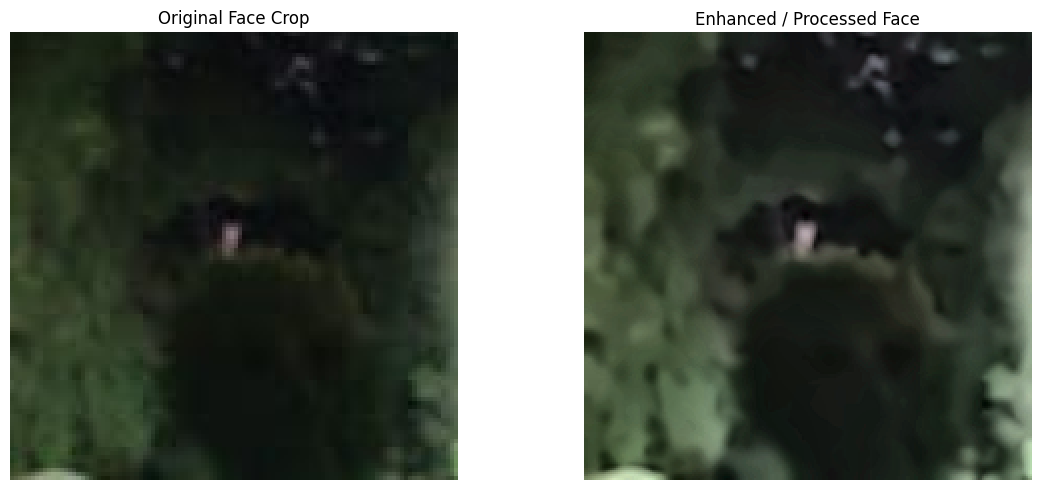

In [20]:
# ============================================================
# VISUALIZE ORIGINAL VS PROCESSED FACE
# ============================================================

if len(face_results) == 0:

    print("No face detected.")

else:

    result = face_results[0]

    original_face = result[
        "original_face"
    ]

    processed_face = result[
        "processed_face"
    ]

    plt.figure(
        figsize=(12, 5)
    )

    plt.subplot(
        1,
        2,
        1
    )

    plt.imshow(
        original_face
    )

    plt.axis("off")

    plt.title(
        "Original Face Crop"
    )

    plt.subplot(
        1,
        2,
        2
    )

    plt.imshow(
        processed_face
    )

    plt.axis("off")

    plt.title(
        "Enhanced / Processed Face"
    )

    plt.tight_layout()

    plt.show()

In [21]:
# ============================================================
# VERIFY FINAL MODEL INPUT
# ============================================================

if len(face_results) > 0:

    tensor = face_results[0][
        "tensor"
    ]

    print(
        "Final tensor shape:",
        tensor.shape
    )

    print(
        "Tensor dtype:",
        tensor.dtype
    )

    print(
        "Minimum:",
        tensor.min().item()
    )

    print(
        "Maximum:",
        tensor.max().item()
    )

    print(
        "Mean:",
        tensor.mean().item()
    )

    print(
        "Std:",
        tensor.std().item()
    )

else:

    print(
        "No face detected."
    )

Final tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Minimum: -2.1179039478302
Maximum: 2.04341721534729
Mean: -1.1846938133239746
Std: 0.5239913463592529


In [22]:
# ============================================================
# SAVE PROCESSED FACE
# ============================================================

if len(face_results) > 0:

    processed_face = face_results[0][
        "processed_face"
    ]

    output_path = (
        PROCESSED_DIR
        / "test_face_processed.jpg"
    )

    processed_face.save(
        output_path
    )

    print(
        "Processed face saved:"
    )

    print(
        output_path
    )

else:

    print(
        "No face detected."
    )

Processed face saved:
e:\Pyhton code\Deep Learning\CNN\Face Recognition Model\data\processed\test_face_processed.jpg


In [23]:
# ============================================================
# STAGE 1 SANITY CHECK
# ============================================================

print("=" * 60)
print("STAGE 1 SANITY CHECK")
print("=" * 60)

checks = {
    "PyTorch device": DEVICE,
    "Face detector": not face_detector.empty(),
    "Test image loaded": TEST_IMAGE_PATH.exists(),
    "Faces detected": len(face_results),
}


for name, value in checks.items():

    print(
        f"{name}: {value}"
    )


if len(face_results) > 0:

    result = face_results[0]

    print("\nFirst face:")

    print(
        "Bounding box:",
        result["box"]
    )

    print(
        "Processed size:",
        result["processed_face"].size
    )

    print(
        "Tensor shape:",
        result["tensor"].shape
    )

    print(
        "Enhancement:",
        result["enhancement_applied"]
    )

    print("\nStage 1 foundation is working!")

else:

    print(
        "\nNo face was detected."
    )

    print(
        "Try another image or adjust "
        "the detector settings."
    )

STAGE 1 SANITY CHECK
PyTorch device: cuda
Face detector: True
Test image loaded: True
Faces detected: 2

First face:
Bounding box: (146, 446, 218, 518)
Processed size: (224, 224)
Tensor shape: torch.Size([3, 224, 224])
Enhancement: True

Stage 1 foundation is working!


In [24]:
# STAGE 2 - CELL 1

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)

print("\nFace detection environment ready!")

OpenCV version: 4.12.0
NumPy version: 2.2.6

Face detection environment ready!


In [25]:
# Load YuNet Face Detector


MODEL_PATH = "face_detection_yunet_2023mar.onnx"

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"YuNet model not found:\n{MODEL_PATH}\n\n"
        "Download the model using the terminal command "
        "given above."
    )

face_detector = cv2.FaceDetectorYN.create(
    MODEL_PATH,
    "",
    (320, 320),
    0.6,
    0.3,
    5000
)

print("YuNet face detector loaded successfully!")

YuNet face detector loaded successfully!


In [26]:
# Face Detection Function

def detect_faces(image, detector=face_detector):

    if image is None:
        raise ValueError("Input image is None.")

    height, width = image.shape[:2]

    # YuNet expects the image size to be provided
    detector.setInputSize((width, height))

    # Detect faces
    _, detections = detector.detect(image)

    faces = []
    scores = []

    if detections is not None:

        for detection in detections:

            # YuNet format:
            # x, y, width, height, landmarks..., confidence

            x, y, w, h = detection[:4]

            confidence = detection[-1]

            # Convert to integers
            x = int(x)
            y = int(y)
            w = int(w)
            h = int(h)

            # Keep coordinates inside image
            x = max(0, x)
            y = max(0, y)

            w = min(w, width - x)
            h = min(h, height - y)

            if w > 0 and h > 0:

                faces.append((x, y, w, h))
                scores.append(float(confidence))

    return faces, scores


print("Face detection function created!")

Face detection function created!


In [27]:
# Face Crop Function

def crop_face(image, box, margin=0.25):

    x, y, w, h = box

    height, width = image.shape[:2]

    # Calculate extra margin
    margin_x = int(w * margin)
    margin_y = int(h * margin)

    # Expanded coordinates
    x1 = max(0, x - margin_x)
    y1 = max(0, y - margin_y)

    x2 = min(width, x + w + margin_x)
    y2 = min(height, y + h + margin_y)

    face_crop = image[y1:y2, x1:x2]

    return face_crop


print("Face cropping function created!")

Face cropping function created!


In [29]:
# Test Face Detection

IMAGE_PATH = r"E:\Pyhton code\Deep Learning\CNN\Face Recognition Model\data\raw\test.jpg"

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise FileNotFoundError(
        f"Could not load image:\n{IMAGE_PATH}"
    )

faces, scores = detect_faces(image)

print("Number of faces detected:", len(faces))

for i, (box, score) in enumerate(zip(faces, scores)):

    print(
        f"Face {i + 1}: "
        f"Box={box}, "
        f"Confidence={score:.2%}"
    )

Number of faces detected: 2
Face 1: Box=(625, 556, 66, 81), Confidence=94.09%
Face 2: Box=(124, 205, 348, 460), Confidence=62.72%


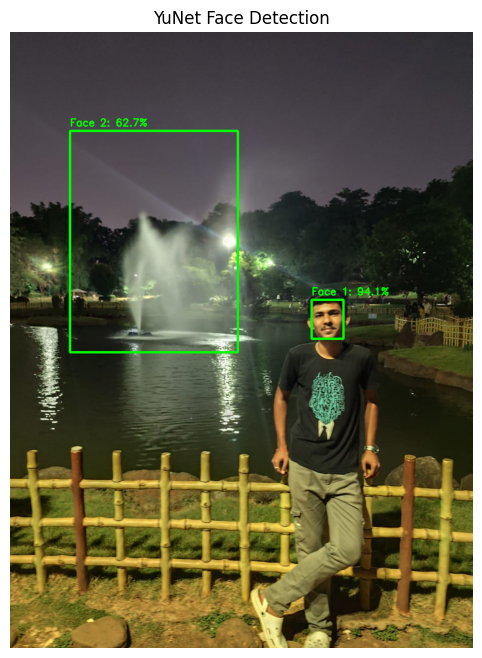

In [30]:
# Visualize Face Detection

display_image = image.copy()

for i, ((x, y, w, h), score) in enumerate(
    zip(faces, scores)
):

    # Draw bounding box
    cv2.rectangle(
        display_image,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        3
    )

    # Label
    label = f"Face {i + 1}: {score:.1%}"

    cv2.putText(
        display_image,
        label,
        (x, max(y - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )


# Convert BGR → RGB
display_rgb = cv2.cvtColor(
    display_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 8))

plt.imshow(display_rgb)

plt.title("YuNet Face Detection")

plt.axis("off")

plt.show()

Best face confidence: 94.09%
Face crop shape: (121, 98, 3)


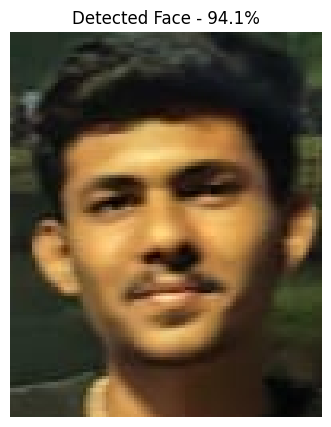

In [31]:
# Extract Face Crop

if len(faces) == 0:

    print("No face detected.")

else:

    # Use highest confidence face
    best_index = np.argmax(scores)

    best_box = faces[best_index]

    best_score = scores[best_index]

    face_crop = crop_face(
        image,
        best_box,
        margin=0.25
    )

    print("Best face confidence:", f"{best_score:.2%}")

    print(
        "Face crop shape:",
        face_crop.shape
    )

    # Display
    face_rgb = cv2.cvtColor(
        face_crop,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(5, 5))

    plt.imshow(face_rgb)

    plt.title(
        f"Detected Face - {best_score:.1%}"
    )

    plt.axis("off")

    plt.show()

In [32]:
# Face Enhancement

def enhance_face(face):
  
    if face is None or face.size == 0:
        raise ValueError("Invalid face image.")

    # --------------------------------------------------------
    # 1. Upscale
    # --------------------------------------------------------

    height, width = face.shape[:2]

    scale = 2

    enhanced = cv2.resize(
        face,
        (width * scale, height * scale),
        interpolation=cv2.INTER_CUBIC
    )

    # --------------------------------------------------------
    # 2. Convert to LAB
    # --------------------------------------------------------

    lab = cv2.cvtColor(
        enhanced,
        cv2.COLOR_BGR2LAB
    )

    l_channel, a_channel, b_channel = cv2.split(lab)

    # --------------------------------------------------------
    # 3. CLAHE
    # --------------------------------------------------------

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l_channel = clahe.apply(l_channel)

    # Merge channels
    lab = cv2.merge(
        (l_channel, a_channel, b_channel)
    )

    enhanced = cv2.cvtColor(
        lab,
        cv2.COLOR_LAB2BGR
    )

    # --------------------------------------------------------
    # 4. Mild denoising
    # --------------------------------------------------------

    enhanced = cv2.bilateralFilter(
        enhanced,
        5,
        40,
        40
    )

    # --------------------------------------------------------
    # 5. Sharpening
    # --------------------------------------------------------

    kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])

    enhanced = cv2.filter2D(
        enhanced,
        -1,
        kernel
    )

    return enhanced


print("Face enhancement function created!")

Face enhancement function created!


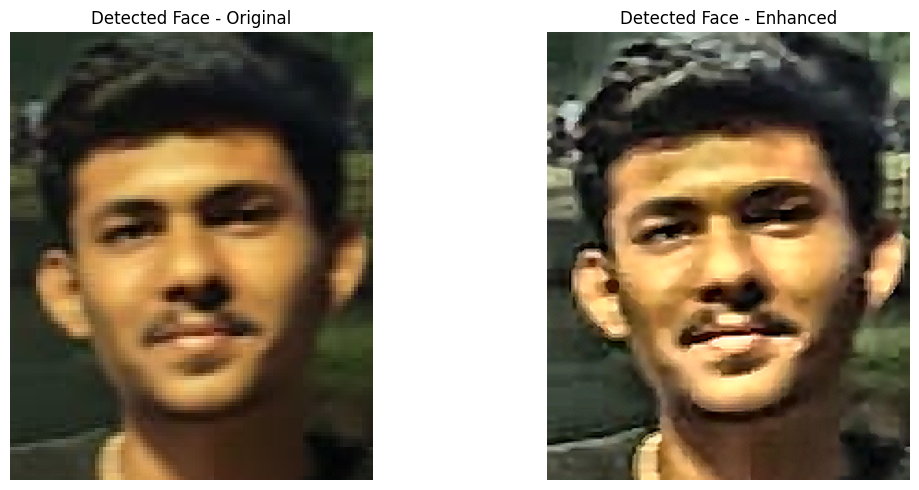

In [33]:
# Compare Face Enhancement

if len(faces) > 0:

    enhanced_face = enhance_face(face_crop)

    original_rgb = cv2.cvtColor(
        face_crop,
        cv2.COLOR_BGR2RGB
    )

    enhanced_rgb = cv2.cvtColor(
        enhanced_face,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(12, 5))

    # Original
    plt.subplot(1, 2, 1)

    plt.imshow(original_rgb)

    plt.title("Detected Face - Original")

    plt.axis("off")

    # Enhanced
    plt.subplot(1, 2, 2)

    plt.imshow(enhanced_rgb)

    plt.title("Detected Face - Enhanced")

    plt.axis("off")

    plt.tight_layout()

    plt.show()

In [34]:
# Complete Face Preprocessing Pipeline

def preprocess_detected_face(
    image,
    detector=face_detector,
    margin=0.25
):
    """
    Complete face preprocessing pipeline.

    Image
      ↓
    Face Detection
      ↓
    Face Crop
      ↓
    Enhancement

    Returns a list of processed faces.
    """

    faces, scores = detect_faces(
        image,
        detector
    )

    results = []

    for box, score in zip(faces, scores):

        # Crop face
        face_crop = crop_face(
            image,
            box,
            margin=margin
        )

        if face_crop.size == 0:
            continue

        # Enhance
        enhanced = enhance_face(
            face_crop
        )

        results.append({
            "box": box,
            "confidence": score,
            "original": face_crop,
            "enhanced": enhanced
        })

    return results


print("Complete preprocessing pipeline created!")

Complete preprocessing pipeline created!


In [35]:
# Test Complete Pipeline

results = preprocess_detected_face(
    image
)

print(
    "Total detected faces:",
    len(results)
)

for i, result in enumerate(results):

    print(
        f"\nFace {i + 1}"
    )

    print(
        "Detection confidence:",
        f"{result['confidence']:.2%}"
    )

    print(
        "Bounding box:",
        result["box"]
    )

    print(
        "Original crop:",
        result["original"].shape
    )

    print(
        "Enhanced crop:",
        result["enhanced"].shape
    )

Total detected faces: 2

Face 1
Detection confidence: 94.09%
Bounding box: (625, 556, 66, 81)
Original crop: (121, 98, 3)
Enhanced crop: (242, 196, 3)

Face 2
Detection confidence: 62.72%
Bounding box: (124, 205, 348, 460)
Original crop: (690, 522, 3)
Enhanced crop: (1380, 1044, 3)


In [36]:
# Save Processed Face

OUTPUT_DIR = "processed_faces"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

for i, result in enumerate(results):

    output_path = os.path.join(
        OUTPUT_DIR,
        f"face_{i + 1}.jpg"
    )

    cv2.imwrite(
        output_path,
        result["enhanced"]
    )

    print(
        "Saved:",
        output_path
    )

Saved: processed_faces\face_1.jpg
Saved: processed_faces\face_2.jpg
